In [1]:
from main_code.raman_spectrum import RamanSpectrum
from main_code.raman_batch import RamanBatch

In [2]:
raman_batch = RamanBatch(root='dataset')

# Apply baseline correction with multiple methods
# results = raman_batch.baseline_on_data(
#    methods=['poly3'],
#    verbose=False
#)
# raman_batch.print_baseline_summary()

RamanBatch: Initializing with root: dataset
Assigned 533 batch IDs in chronological order
  Earliest: 01.04.2025 13:52:35
  Latest: 16.01.2026 18:10:36
Reshaping all spectra to range: (100, 1000)
Reshaped all 533 spectra with window: (100, 1000)

AVAILABLE SPECTRUM DATA ATTRIBUTES

Full spectrum data (always available):
  • x, y → Full wavenumber axis and normalized intensity
  • raw_y → Original unnormalized intensity values

Windowed/Reshaped data (created after reshape_range):
  • window_wavenumbers (alias: p)
  • window_intensity (alias: q)

Baseline-corrected data (created after baseline correction):
  • baseline_wavenumbers (alias: u)
  • baseline_corrected_intensity (alias: v)
  • current_baseline

Legacy aliases (p, q, u, v) maintained for backward compatibility.



In [3]:
results = raman_batch.baseline_on_data(
    methods=['poly3'],
    verbose=False
)
raman_batch.print_baseline_summary()

Batch Baseline Correction Summary

Method: poly3
  Success Rate: 100.0% (533/533)
  RMSE - Mean: 0.065152, Std: 0.015924
         Min: 0.022251, Max: 0.118168
  MAE - Mean: 0.042262, Std: 0.009647


In [4]:
all_raman = raman_batch.all_raman
import random
example_spectrum = random.choice(list(all_raman.values()))
example_spectrum.filepath

'dataset/B5V/B5V_24.txt'

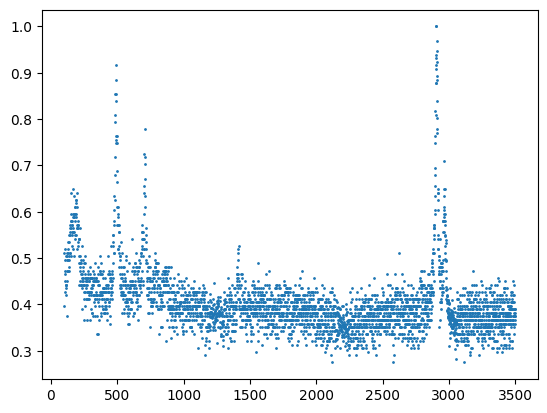

In [5]:
import matplotlib.pyplot as plt
plt.scatter(example_spectrum.x, example_spectrum.y, s=1)

***
## Inspecting the dataset
***

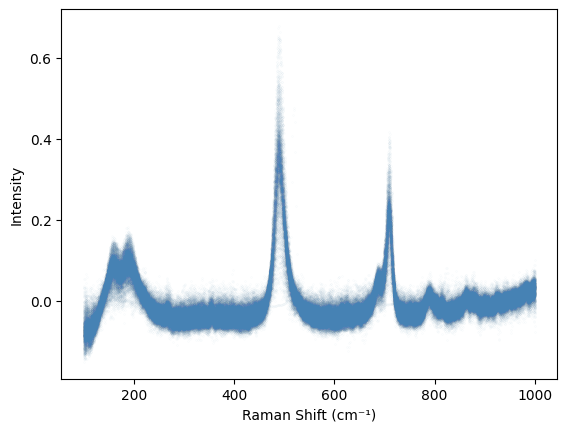

In [6]:
import matplotlib.pyplot as plt
import numpy as np
for spectrum in all_raman.values():
    plt.scatter(spectrum.u, spectrum.v, alpha=0.5, s=0.001, c='steelblue')
plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.show()

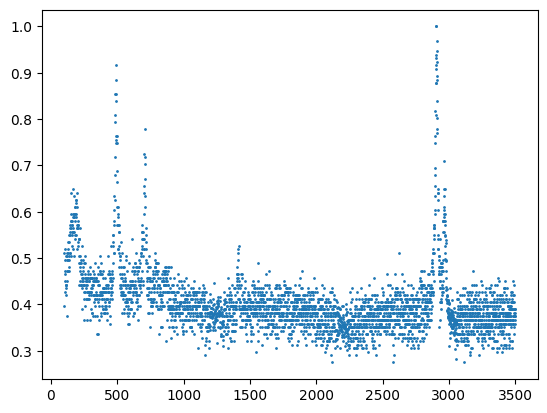

In [7]:
x = example_spectrum.x
y = example_spectrum.y
plt.scatter(x, y, s=1)

In [8]:
shapes = set()
for k,v in all_raman.items():
    spectrum_shape = v.u.shape
    shapes.add(spectrum_shape)
    

In [9]:
shapes

{(746,)}

In [10]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets

# --- 1. Data Preparation (Your original code) ---
data_matrix = []
meta_info = []

for key, spectrum in all_raman.items():
    if hasattr(spectrum, 'v'):
        # return spectrum v until its length is 800
        data_matrix.append(spectrum.v[:743])
        meta_info.append({
            "Filename": getattr(spectrum, 'filepath', 'N/A'),
            "Acquired": getattr(spectrum, 'acquired', 'N/A'),
            "ID": key
        })

data_matrix = np.array(data_matrix)
# Center data
data_matrix -= np.mean(data_matrix, axis=0)

# SVD
U, S, VT = np.linalg.svd(data_matrix, full_matrices=False)

# Create a DataFrame for Plotly
df = pd.DataFrame(meta_info)
df['PC1'] = U[:, 0]
df['PC2'] = U[:, 1]

# --- 2. Create the Base Figure ---
# We use the same px logic, but we don't do .show() yet
fig = px.scatter(
    df, 
    x='PC1', 
    y='PC2', 
    hover_data=['Filename', 'Acquired', 'ID'], 
    title='SVD Analysis of Raman Spectra (Searchable)'
)

fig.update_traces(marker=dict(size=10, color='blue', opacity=0.7))

# --- 3. Convert to an Interactive Widget ---
# FigureWidget allows us to update data without re-rendering the whole plot
f_widget = go.FigureWidget(fig)

# --- 4. Build the Search Logic ---

# Create the Text Input Box
search_box = widgets.Text(
    value='',
    placeholder='Enter Filename to search...',
    description='Search:',
    disabled=False,
    layout=widgets.Layout(width='50%')
)

# Create a Label to show status (e.g., "Found 3 matches")
status_label = widgets.Label(value="Ready")

def process_search(change):
    """
    Callback function triggered whenever the text box changes.
    """
    search_text = change.new.strip()
    
    # Access the scatter trace (usually the first trace at index 0)
    scatter = f_widget.data[0]
    
    # Reset if search is empty
    if not search_text:
        with f_widget.batch_update():
            scatter.marker.color = 'blue'
            scatter.marker.size = 10
            scatter.marker.opacity = 0.7
        status_label.value = "Ready"
        return

    # Find indices where Filename contains the search text
    # 'case=False' makes it insensitive (A vs a)
    matches = df['Filename'].astype(str).str.contains(search_text, case=False, na=False)
    
    match_count = matches.sum()
    
    if match_count == 0:
        status_label.value = f"No matches found for '{search_text}'"
        # Optional: Reset colors if nothing found, or keep previous state
        return

    # Create color and size arrays based on matches
    # Default: Blue/Size 10. Match: Red/Size 25
    colors = np.where(matches, 'red', 'lightgray') 
    sizes = np.where(matches, 25, 8)
    opacities = np.where(matches, 1.0, 0.3) # Dim non-matches
    
    # Batch update ensures the plot updates smoothly in one frame
    with f_widget.batch_update():
        scatter.marker.color = colors
        scatter.marker.size = sizes
        scatter.marker.opacity = opacities
        
    status_label.value = f"Found {match_count} match(es)"

# Connect the text box to the function
search_box.observe(process_search, names='value')

# --- 5. Display Layout ---
# VBox stacks the search bar on top of the plot
widgets.VBox([
    widgets.HBox([search_box, status_label]), 
    f_widget
])

In [11]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# --- 1. Data Preparation (Your original code) ---
data_matrix = []
meta_info = []

for key, spectrum in all_raman.items():
    if hasattr(spectrum, 'v'):
        data_matrix.append(spectrum.v[:743])
        meta_info.append({
            "Filename": getattr(spectrum, 'filepath', 'N/A'),
            "Acquired": getattr(spectrum, 'acquired', 'N/A'),
            "ID": key
        })

data_matrix = np.array(data_matrix)
# Center data
data_matrix -= np.mean(data_matrix, axis=0)

# SVD
U, S, VT = np.linalg.svd(data_matrix, full_matrices=False)

# Create a DataFrame for Plotly
df = pd.DataFrame(meta_info)
df['PC1'] = U[:, 0]
df['PC2'] = U[:, 1]

# --------------------------------------------------------------------------

# --- 2. Create the Base Figure ---
fig = px.scatter(
    df, 
    x='PC1', 
    y='PC2', 
    # Remove hover details to prevent the blue box from appearing
    hover_data=[],  # Empty list removes hover details
    title='SVD Analysis (Select point for details)'
)

# Remove hover tooltip entirely
fig.update_traces(
    marker=dict(size=10, color='blue', opacity=0.7),
    hoverinfo='skip'  # This disables hover completely
)

fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0), 
    height=500,
    # Configure selection behavior
    dragmode='lasso',  # Default to lasso selection
    clickmode='event+select'  # Enable both click and select events
)

# --- 3. Convert to Interactive Widget ---
f_widget = go.FigureWidget(fig)

# --- 4. Build the Controls & Details Panel ---

# Search Box
search_box = widgets.Text(
    value='',
    placeholder='Search Filename...',
    description='Search:',
    layout=widgets.Layout(width='98%')
)

# Status Label
status_label = widgets.Label(value="Ready")

# Detail Box (Moved to the side to avoid overlap)
# This uses HTML to format the details nicely
details_html = widgets.HTML(
    value="<b>Click on a point to see details here.</b>",
    layout=widgets.Layout(border='1px solid #ccc', padding='10px', height='300px', width='98%')
)

# Lasso Selection Results Box
lasso_results_html = widgets.HTML(
    value="<b>Lasso selected IDs will appear here.</b>",
    layout=widgets.Layout(border='1px solid #ccc', padding='10px', height='200px', width='98%')
)

# Selection mode toggle button
selection_mode = widgets.ToggleButtons(
    options=['Lasso', 'Rectangle'],
    value='Lasso',
    description='Selection Mode:',
    tooltips=['Lasso selection', 'Rectangle selection']
)

def update_selection_mode(change):
    """Update the drag mode based on selection mode"""
    with f_widget.batch_update():
        if change.new == 'Lasso':
            f_widget.update_layout(dragmode='lasso')
        else:
            f_widget.update_layout(dragmode='select')

selection_mode.observe(update_selection_mode, names='value')

# --- 5. Interaction Logic ---

# Track current colors for highlighting
current_colors = ['blue'] * len(df)
current_sizes = [10] * len(df)
current_opacities = [0.7] * len(df)

# Search Logic
def process_search(change):
    global current_colors, current_sizes, current_opacities
    
    search_text = change.new.strip()
    scatter = f_widget.data[0]
    
    if not search_text:
        with f_widget.batch_update():
            scatter.marker.color = 'blue'
            scatter.marker.size = 10
            scatter.marker.opacity = 0.7
            # Reset tracking arrays
            current_colors = ['blue'] * len(df)
            current_sizes = [10] * len(df)
            current_opacities = [0.7] * len(df)
        status_label.value = "Ready"
        return

    matches = df['Filename'].astype(str).str.contains(search_text, case=False, na=False)
    match_count = matches.sum()
    
    if match_count == 0:
        status_label.value = f"No matches for '{search_text}'"
        return

    colors = np.where(matches, 'red', 'lightgray') 
    sizes = np.where(matches, 15, 6)
    opacities = np.where(matches, 1.0, 0.2)
    
    with f_widget.batch_update():
        scatter.marker.color = colors.tolist()
        scatter.marker.size = sizes.tolist()
        scatter.marker.opacity = opacities.tolist()
        
        # Update tracking arrays
        current_colors = colors.tolist()
        current_sizes = sizes.tolist()
        current_opacities = opacities.tolist()
        
    status_label.value = f"Found {match_count} match(es)"

search_box.observe(process_search, names='value')

# Click Logic (Populate the Side Panel)
def update_details(trace, points, selector):
    if not points.point_inds:
        return
    
    # Get the index of the clicked point
    ind = points.point_inds[0]
    row = df.iloc[ind]
    
    # Update the HTML widget on the right
    details_html.value = f"""
    <h3>Details</h3>
    <p><b>ID:</b> {row['ID']}</p>
    <p><b>Filename:</b> {row['Filename']}</p>
    <p><b>Acquired:</b> {row['Acquired']}</p>
    <hr>
    <p><b>PC1:</b> {row['PC1']:.4f}</p>
    <p><b>PC2:</b> {row['PC2']:.4f}</p>
    """

f_widget.data[0].on_click(update_details)

# Lasso Selection Logic
def handle_lasso_selection(trace, points, selector):
    """Handle lasso/rectangle selection and display selected IDs"""
    global current_colors, current_sizes, current_opacities
    
    if not points.point_inds:
        return
    
    # Get indices of selected points
    selected_indices = points.point_inds
    
    # Get corresponding IDs from df
    selected_ids = df.iloc[selected_indices]['ID'].tolist()
    
    # Count unique IDs
    unique_ids = set(selected_ids)
    
    # Create formatted HTML output with Python-style list
    if len(selected_ids) == 0:
        lasso_results_html.value = "<b>No points selected.</b>"
    else:
        # Format as Python-style list
        id_list_str = str(selected_ids)
        
        lasso_results_html.value = f"""
        <h3>Lasso Selection Results</h3>
        <p><b>Total points selected:</b> {len(selected_ids)}</p>
        <p><b>Unique IDs:</b> {len(unique_ids)}</p>
        <hr>
        <div style="overflow-y: auto; max-height: 120px;">
        <b>Selected IDs:</b><br>
        <code style="background-color: #f5f5f5; padding: 5px; border-radius: 3px;">{id_list_str}</code>
        </div>
        """
    
    # Highlight selected points
    with f_widget.batch_update():
        # Create copies of current colors, sizes, and opacities
        new_colors = current_colors.copy()
        new_sizes = current_sizes.copy()
        new_opacities = current_opacities.copy()
        
        # Highlight selected points
        for idx in selected_indices:
            new_colors[idx] = 'red'
            new_opacities[idx] = 1.0
            new_sizes[idx] = 12
        
        # Apply the updates
        trace.marker.color = new_colors
        trace.marker.opacity = new_opacities
        trace.marker.size = new_sizes

# Connect lasso selection handler
f_widget.data[0].on_selection(handle_lasso_selection)

# Clear selection button
clear_button = widgets.Button(
    description='Clear Selection',
    button_style='info',
    tooltip='Clear lasso selection and reset colors'
)

def clear_selection(b):
    """Clear lasso selection and reset plot"""
    global current_colors, current_sizes, current_opacities
    
    # Check if search is active
    search_text = search_box.value.strip()
    
    with f_widget.batch_update():
        scatter = f_widget.data[0]
        
        if not search_text:
            # No search active, reset to default
            scatter.marker.color = 'blue'
            scatter.marker.size = 10
            scatter.marker.opacity = 0.7
            current_colors = ['blue'] * len(df)
            current_sizes = [10] * len(df)
            current_opacities = [0.7] * len(df)
        else:
            # Search is active, reapply search highlighting
            matches = df['Filename'].astype(str).str.contains(search_text, case=False, na=False)
            colors = np.where(matches, 'red', 'lightgray') 
            sizes = np.where(matches, 15, 6)
            opacities = np.where(matches, 1.0, 0.2)
            
            scatter.marker.color = colors.tolist()
            scatter.marker.size = sizes.tolist()
            scatter.marker.opacity = opacities.tolist()
            
            current_colors = colors.tolist()
            current_sizes = sizes.tolist()
            current_opacities = opacities.tolist()
        
        # Clear selection
        if hasattr(scatter, 'selectedpoints'):
            scatter.selectedpoints = None
    
    # Clear lasso results display
    lasso_results_html.value = "<b>Lasso selected IDs will appear here.</b>"

clear_button.on_click(clear_selection)

# --- 6. Layout Composition (Side-by-Side) ---

# Left Panel: The Plot
left_panel = widgets.VBox([f_widget], layout=widgets.Layout(width='65%'))

# Right Panel: Controls and Details
right_panel = widgets.VBox(
    [
        widgets.HTML("<h3>Controls</h3>"),
        selection_mode,
        search_box, 
        status_label,
        clear_button,
        widgets.HTML("<br><h3>Item Details</h3>"),
        details_html,
        widgets.HTML("<br><h3>Lasso Selection</h3>"),
        lasso_results_html
    ], 
    layout=widgets.Layout(width='35%', padding='10px')
)

# Combine
ui = widgets.HBox([left_panel, right_panel])
display(ui)

    'data': [{'hoverinfo': 'skip',
              'hovertemplate':…

In [12]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets

# --- 1. Data Preparation ---
data_matrix = []
meta_info = []

# Assuming 'all_raman' is defined in your previous cells
# We iterate to build the matrix for SVD
for key, spectrum in all_raman.items():
    if hasattr(spectrum, 'v'):
        data_matrix.append(spectrum.v[:743])  # Ensure we only take the first 743 points
        meta_info.append({
            "Filename": getattr(spectrum, 'filepath', 'N/A'),
            "Acquired": getattr(spectrum, 'acquired', 'N/A'),
            "ID": key
        })

data_matrix = np.array(data_matrix)
# Center data (SVD requires mean-centered data)
data_matrix -= np.mean(data_matrix, axis=0)

# Calculate SVD
U, S, VT = np.linalg.svd(data_matrix, full_matrices=False)

# Create a DataFrame for the Scatter Plot
df = pd.DataFrame(meta_info)
df['PC1'] = U[:, 0]
df['PC2'] = U[:, 1]

# --------------------------------------------------------------------------

# --- 2. Create the Base Figure (Scatter) ---
fig = px.scatter(
    df, 
    x='PC1', 
    y='PC2', 
    hover_data=['Filename', 'Acquired', 'ID'], 
    title='SVD Analysis (Click point to plot spectrum)'
)

fig.update_traces(marker=dict(size=10, color='blue', opacity=0.7))
fig.update_layout(margin=dict(l=0, r=0, t=30, b=0), height=500, dragmode='zoom')

# Convert to Interactive FigureWidget
f_widget = go.FigureWidget(fig)

# --- 3. Create the Spectrum Figure ---
spec_fig = go.Figure()
spec_fig.update_layout(
    title="Selected Spectrum",
    margin=dict(l=40, r=20, t=40, b=40),
    height=300,
    xaxis_title="Raman Shift (cm-1)",
    yaxis_title="Intensity"
)
# Add a placeholder trace
spec_fig.add_trace(go.Scatter(x=[], y=[], mode='lines', name='Spectrum'))

spectrum_widget = go.FigureWidget(spec_fig)


# --- 4. Build the Controls ---

search_box = widgets.Text(
    value='',
    placeholder='Search Filename...',
    description='Search:',
    layout=widgets.Layout(width='98%')
)

status_label = widgets.Label(value="Ready")

# --- 5. Interaction Logic ---

# Search Filter Logic
def process_search(change):
    search_text = change.new.strip()
    scatter = f_widget.data[0]
    
    if not search_text:
        with f_widget.batch_update():
            scatter.marker.color = 'blue'
            scatter.marker.size = 10
            scatter.marker.opacity = 0.7
        status_label.value = "Ready"
        return

    matches = df['Filename'].astype(str).str.contains(search_text, case=False, na=False)
    match_count = matches.sum()
    
    if match_count == 0:
        status_label.value = f"No matches for '{search_text}'"
        return

    colors = np.where(matches, 'red', 'lightgray') 
    sizes = np.where(matches, 15, 6)
    opacities = np.where(matches, 1.0, 0.2)
    
    with f_widget.batch_update():
        scatter.marker.color = colors
        scatter.marker.size = sizes
        scatter.marker.opacity = opacities
        
    status_label.value = f"Found {match_count} match(es)"

search_box.observe(process_search, names='value')

# Click Logic (Plot the Spectrum)
def update_spectrum_plot(trace, points, selector):
    if not points.point_inds:
        return
    
    # Get the index of the clicked point
    ind = points.point_inds[0]
    row = df.iloc[ind]
    spec_id = row['ID']
    
    if spec_id in all_raman:
        spectrum = all_raman[spec_id]
        
        # Get Data
        y_data = spectrum.y
        if hasattr(spectrum, 'x'):
            x_data = spectrum.x
        else:
            x_data = np.arange(len(y_data))
            
        # Update the spectrum plot
        with spectrum_widget.batch_update():
            # 1. Clear existing traces
            spectrum_widget.data = []
            
            # 2. Add new trace (ensure name is a string)
            spectrum_widget.add_trace(go.Scatter(
                x=x_data, 
                y=y_data, 
                mode='lines', 
                name=str(spec_id)
            ))
            
            # 3. Update title
            spectrum_widget.layout.title = f"Spectrum: {row['Filename']}"
            
            # 4. FORCE FIXED X RANGE (100–3500 cm-1)
            spectrum_widget.layout.xaxis.range = [100, 3500]
            spectrum_widget.layout.xaxis.autorange = False

            # Y can still autoscale
            spectrum_widget.layout.yaxis.autorange = True


# Attach the click event
f_widget.data[0].on_click(update_spectrum_plot)

# --- 6. Layout Composition ---

left_panel = widgets.VBox([f_widget], layout=widgets.Layout(width='60%'))

right_panel = widgets.VBox(
    [
        widgets.HTML("<b>Filter:</b>"),
        search_box, 
        status_label, 
        widgets.HTML("<hr>"),
        spectrum_widget
    ], 
    layout=widgets.Layout(width='40%', padding='10px')
)

ui = widgets.HBox([left_panel, right_panel])
display(ui)


    'data': [{'customdata': array([['dataset/A2U/A2_1.txt', '01.0…

In [13]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets


# --- 1. Data Preparation (Your original code) ---
data_matrix = []
meta_info = []

for key, spectrum in all_raman.items():
    if hasattr(spectrum, 'v'):
        data_matrix.append(spectrum.v[:743])
        meta_info.append({
            "Filename": getattr(spectrum, 'filepath', 'N/A'),
            "Acquired": getattr(spectrum, 'acquired', 'N/A'),
            "ID": key
        })

data_matrix = np.array(data_matrix)
# Center data
data_matrix -= np.mean(data_matrix, axis=0)

# SVD
U, S, VT = np.linalg.svd(data_matrix, full_matrices=False)

# Create a DataFrame for Plotly
df = pd.DataFrame(meta_info)
df['PC1'] = U[:, 0]
df['PC2'] = U[:, 1]

# ---------------------------------------------------------------------
# --- 2. Create the Base Figure ---
fig = px.scatter(
    df, 
    x='PC1', 
    y='PC2', 
    hover_data=['Filename', 'ID'], 
    title='SVD Analysis (Zoom to filter list)'
)

fig.update_traces(marker=dict(size=10, color='blue', opacity=0.7))
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0), height=600, dragmode='zoom')

f_widget = go.FigureWidget(fig)

# --- 3. UI Components ---

# Search
search_box = widgets.Text(
    placeholder='Search Filename...', 
    description='Search:', 
    layout=widgets.Layout(width='98%')
)
status_label = widgets.Label(value="Ready")

# List
visible_ids_label = widgets.Label(value=f"Visible Batch IDs (Total: {len(df['ID'].unique())}):")
visible_ids_list = widgets.Select(
    options=sorted(df['ID'].unique()),
    description='',
    rows=15,
    disabled=False,
    layout=widgets.Layout(width='98%', height='250px')
)

# Export Button & Feedback
export_btn = widgets.Button(
    description='Save List to "visible_ids.txt"',
    icon='save',
    button_style='primary',
    layout=widgets.Layout(width='98%')
)
export_status = widgets.Label(value="")

# --- 4. Logic Implementation ---

# SEARCH LOGIC
def process_search(change):
    search_text = change.new.strip()
    scatter = f_widget.data[0]
    
    if not search_text:
        with f_widget.batch_update():
            scatter.marker.color = 'blue'
            scatter.marker.size = 10
            scatter.marker.opacity = 0.7
        status_label.value = "Ready"
        return

    matches = df['Filename'].astype(str).str.contains(search_text, case=False, na=False)
    
    with f_widget.batch_update():
        scatter.marker.color = np.where(matches, 'red', 'lightgray')
        scatter.marker.size = np.where(matches, 15, 6)
        scatter.marker.opacity = np.where(matches, 1, 0.2)
        
    status_label.value = f"Found {matches.sum()} match(es)"

search_box.observe(process_search, names='value')

# ZOOM LOGIC
def handle_zoom(layout, xrange, yrange):
    if xrange is None:
        x_min, x_max = df['PC1'].min(), df['PC1'].max()
    else:
        x_min, x_max = xrange
        
    if yrange is None:
        y_min, y_max = df['PC2'].min(), df['PC2'].max()
    else:
        y_min, y_max = yrange

    mask = (
        (df['PC1'] >= x_min) & (df['PC1'] <= x_max) &
        (df['PC2'] >= y_min) & (df['PC2'] <= y_max)
    )
    
    visible_df = df[mask]
    unique_ids = sorted(visible_df['ID'].unique().astype(str))
    
    visible_ids_list.options = unique_ids
    visible_ids_label.value = f"Visible Batch IDs (Count: {len(unique_ids)}):"

f_widget.layout.on_change(handle_zoom, 'xaxis.range', 'yaxis.range')

# EXPORT LOGIC (Save to TXT)
def on_export_click(b):
    items = visible_ids_list.options
    
    if not items:
        export_status.value = "List is empty, nothing to save."
        return

    filename = "visible_ids.txt"
    try:
        with open(filename, "w") as f:
            f.write("\n".join(items))
        
        # Update feedback label
        export_status.value = f"Successfully saved {len(items)} IDs to: {filename}"
    except Exception as e:
        export_status.value = f"Error saving file: {str(e)}"

export_btn.on_click(on_export_click)

# --- 5. Layout Composition ---

left_panel = widgets.VBox([f_widget], layout=widgets.Layout(width='65%'))

right_panel = widgets.VBox(
    [
        widgets.HTML("<b>Filter by Filename:</b>"),
        search_box, 
        status_label,
        widgets.HTML("<hr><b>Visible Batch IDs:</b><br><i>Zoom/Pan chart to update</i>"),
        visible_ids_label,
        visible_ids_list,
        widgets.HTML("<br>"),
        export_btn,
        export_status
    ], 
    layout=widgets.Layout(width='35%', padding='10px')
)

ui = widgets.HBox([left_panel, right_panel])
display(ui)


    'data': [{'customdata': array([['dataset/A2U/A2_1.txt', 0],
 …

***
## Clusterization
***

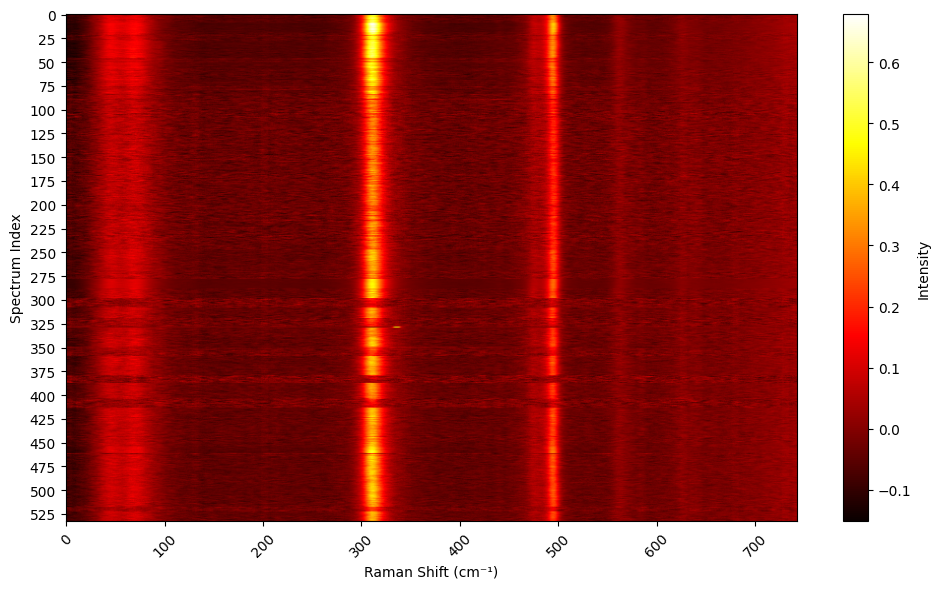

In [15]:
# Now we create a matrix that stores spectra data as rows and the intensity values as columns
data_matrix = []

for spectrum in all_raman.values():
    data_matrix.append(spectrum.v[:743])  # Assuming we want the first 800 points
data_matrix = np.array(data_matrix)

# Plot the matrix as a heatmap
plt.figure(figsize=(10, 6))
im = plt.imshow(data_matrix, aspect='auto', cmap='hot')
cbar = plt.colorbar(im)
cbar.set_label('Intensity')
plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Spectrum Index')

# Set ticks every 50 on x axis and every 25 on y axis, rotate x ticks 45 degrees
yticks = np.arange(0, data_matrix.shape[0] + 1, 25)
plt.xticks(rotation=45)
plt.yticks(yticks)

plt.tight_layout()
plt.show()

In [16]:
import plotly.graph_objects as go
import ipywidgets as widgets
import numpy as np
from IPython.display import display

# --- 1. Data Preparation ---
data_rows = []
metadata_list = []

# Iterate over all spectra to collect data and metadata simultaneously
for spectrum in all_raman.values():
    data_rows.append(spectrum.v[:743])  # Assuming we want the first 800 points
    # # Ensure necessary attributes exist
    # if hasattr(spectrum, 'v'):
    #     # Baseline correction
    #     based_v = spectrum.v - np.min(spectrum.v)
    #     data_rows.append(based_v)
        
    # Collect details for this row
    metadata_list.append({
        "Batch ID": getattr(spectrum, 'batch_id', 'N/A'),
        "Filename": getattr(spectrum, 'filepath', 'N/A'),
        "Acquired": getattr(spectrum, 'acquired', 'N/A')
    })

data_matrix = np.array(data_rows)

if data_matrix.size > 0:
    # --- 2. Create Interactive Heatmap ---
    
    # Define axes
    # X-axis: Linearly spaced from 100 to 1100 based on number of data points
    x_axis = np.linspace(100, 1100, data_matrix.shape[1])
    # Y-axis: Spectrum Index (0 to N)
    y_axis = np.arange(data_matrix.shape[0])

    # Create the FigureWidget
    fig = go.FigureWidget(
        data=go.Heatmap(
            z=data_matrix,
            x=x_axis,
            y=y_axis,
            colorscale='Hot',
            colorbar=dict(title='Intensity'),
            # We disable standard hover info to rely on our side panel, 
            # or you can set it to 'y' to see the index on the plot.
            hoverinfo='none' 
        )
    )

    fig.update_layout(
        title='Raman Spectra Heatmap',
        xaxis_title='Raman Shift (cm⁻¹)',
        yaxis_title='Spectrum Index',
        width=800,
        height=600,
        margin=dict(l=50, r=50, b=50, t=50)
    )

    # --- 3. Create Details Panel ---
    
    details_header = widgets.HTML('<h3>Row Details</h3>')
    details_content = widgets.HTML('<i>Hover over a row to see details...</i>')

    side_panel = widgets.VBox(
        [details_header, details_content],
        layout=widgets.Layout(
            width='300px', 
            border='1px solid #ddd', 
            padding='10px', 
            margin='0 0 0 20px' 
        )
    )

    # --- 4. Define Hover Interaction ---
    
    def on_hover(trace, points, state):
        # points.ys contains the y-coordinates (row indices) of the hovered pixels
        if points.ys:
            row_idx = int(points.ys[0])
            
            # Retrieve metadata for this row
            if 0 <= row_idx < len(metadata_list):
                info = metadata_list[row_idx]
                
                # Update the side panel HTML
                details_content.value = (
                    f"<b>Spectrum Index:</b> {row_idx}<br>"
                    f"<b>Batch ID:</b> {info['Batch ID']}<br><br>"
                    f"<b>Filename:</b><br>{info['Filename']}<br><br>"
                    f"<b>Acquired:</b><br>{info['Acquired']}"
                )

    # Attach the callback to the heatmap trace
    fig.data[0].on_hover(on_hover)

    # --- 5. Display the Layout ---
    main_layout = widgets.HBox(
        [fig, side_panel],
        layout=widgets.Layout(align_items='flex-start')
    )
    
    display(main_layout)

else:
    print("No data available to plot after filtering.")


    'data': [{'colorbar': {'title': {'text': 'Intensity'}},
              'color…

***
## Inspecting by dates
***


In [18]:
# Checking the different dates

dates = []
for idx, spectrum in raman_batch.all_raman.items():
    date = spectrum.date_acquired
    if date not in dates:
        dates.append(date)
print(dates)

['01.04.2025', '07.04.2025', '18.06.2025', '03.11.2025', '09.01.2026', '12.01.2026', '13.01.2026', '14.01.2026', '16.01.2026']


In [19]:
dates

['01.04.2025',
 '07.04.2025',
 '18.06.2025',
 '03.11.2025',
 '09.01.2026',
 '12.01.2026',
 '13.01.2026',
 '14.01.2026',
 '16.01.2026']

In [20]:
# # Group spectra by acquisition date (using existing `dates` list)
# groups = {d: [] for d in dates}   # dates is: ['01.04.2025', '07.04.2025', '18.06.2025', '03.11.2025']
# groups.setdefault('Other', [])    # catch-all for spectra without a matching date
groups = {d: [] for d in dates}
print(groups)
groups['Other'] = []

{'01.04.2025': [], '07.04.2025': [], '18.06.2025': [], '03.11.2025': [], '09.01.2026': [], '12.01.2026': [], '13.01.2026': [], '14.01.2026': [], '16.01.2026': []}


In [21]:
# # Group spectra by acquisition date (using existing `dates` list)
# groups = {d: [] for d in dates}   # dates is: ['01.04.2025', '07.04.2025', '18.06.2025', '03.11.2025']
# groups.setdefault('Other', [])    # catch-all for spectra without a matching date

for idx, spectrum in all_raman.items():
    # TODO: Apply filters to ensure reproducibility in conditions
    if spectrum.metadata.get('ND Filter', 'No Filter') == '25%':

        # Prefer an explicit date attribute if present
        date_str = spectrum.date_acquired
        if not date_str:
            # Fallback to the 'acquired' timestamp (format: 'DD.MM.YYYY HH:MM:SS')
            acq = getattr(spectrum, 'acquired', '')
            if isinstance(acq, str) and acq:
                date_str = acq.split()[0]

        if date_str in groups:
            groups[date_str].append(spectrum)
        else:
            groups['Other'].append(spectrum)

# Quick summary
print({k: len(v) for k, v in groups.items()})

{'01.04.2025': 0, '07.04.2025': 28, '18.06.2025': 32, '03.11.2025': 160, '09.01.2026': 50, '12.01.2026': 30, '13.01.2026': 75, '14.01.2026': 50, '16.01.2026': 79, 'Other': 0}


In [22]:
filters = {}

for idx, spectrum in all_raman.items():
    filter_value = spectrum.metadata.get('ND Filter', 'No Filter')
    if filter_value not in filters:
        filters[filter_value] = []
    filters[filter_value].append(spectrum)
print({k: len(v) for k, v in filters.items()})

{'100%': 29, '25%': 504}


***
## By Radiation
***

In [23]:
import re 

pattern_h = r"(?:A|B)[1-5]"
groups = {}

for idx, spectrum in all_raman.items():
    if spectrum.metadata.get('ND Filter', 'No Filter') == '25%':
        if re.search(pattern_h,spectrum.filepath):
            possible_key = re.search(pattern_h,spectrum.filepath).group(0)[1]
            if possible_key not in groups:
                groups[possible_key] = []
            groups[possible_key].append(spectrum)
print({k: len(v) for k, v in groups.items()})

{'5': 94, '1': 89, '2': 94, '3': 115, '4': 112}


In [24]:
groups

{'5': [RamanSpectrum: dataset/_B5/_B5_8.txt,
  RamanSpectrum: dataset/_B5/_B5_1.txt,
  RamanSpectrum: dataset/_B5/_B5_2.txt,
  RamanSpectrum: dataset/_B5/_B5_7.txt,
  RamanSpectrum: dataset/_B5/_B5_6.txt,
  RamanSpectrum: dataset/_B5/_B5_3.txt,
  RamanSpectrum: dataset/_B5/_B5_4.txt,
  RamanSpectrum: dataset/_B5/_B5_5.txt,
  RamanSpectrum: dataset/A5/A5_1.txt,
  RamanSpectrum: dataset/A5/A5_2.txt,
  RamanSpectrum: dataset/A5/A5_3.txt,
  RamanSpectrum: dataset/A5/A5_4.txt,
  RamanSpectrum: dataset/A5/A5_5.txt,
  RamanSpectrum: dataset/A5/A5_6.txt,
  RamanSpectrum: dataset/A5/A5_7.txt,
  RamanSpectrum: dataset/A5/A5_8.txt,
  RamanSpectrum: dataset/A5/A5_9.txt,
  RamanSpectrum: dataset/A5/A5_10.txt,
  RamanSpectrum: dataset/A5/A5_11.txt,
  RamanSpectrum: dataset/A5/A5_12.txt,
  RamanSpectrum: dataset/A5/A5_13.txt,
  RamanSpectrum: dataset/A5/A5_14.txt,
  RamanSpectrum: dataset/A5/A5_15.txt,
  RamanSpectrum: dataset/A5/A5_16.txt,
  RamanSpectrum: dataset/B5/B5_1.txt,
  RamanSpectrum: datas

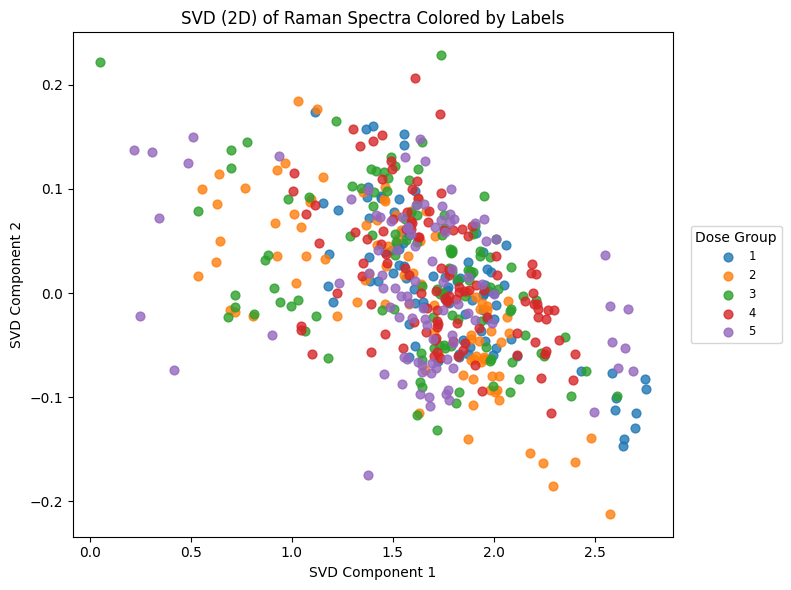

In [28]:
# Build X and Y from existing `groups`
X = []
Y = []

for label, spectra_list in groups.items():
    for spectrum in spectra_list:
        X.append(spectrum.v)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

# Ensure X is 2D (n_samples, n_features)
if X.ndim == 1:
    X = X.reshape(-1, 1)

# SVD (2 components)
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X)

# 2D scatter plot of the first 2 components
fig, ax = plt.subplots(figsize=(8, 6))

unique_labels = np.unique(Y)
# Ten contrasting colors (hex) - will cycle if more than 10 labels
colors_list = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # safety orange
    "#2ca02c",  # cooked asparagus green
    "#d62728",  # brick red
    "#9467bd",  # muted purple
    "#8c564b",  # chestnut brown
    "#e377c2",  # rosy pink
    "#7f7f7f",  # medium gray
    "#bcbd22",  # curry yellow-green
    "#17becf"   # blue-teal
]

for i, label in enumerate(unique_labels):
    inds = np.where(Y == label)[0]
    ax.scatter(
        X_svd[inds, 0],
        X_svd[inds, 1],
        label=label,
        s=40,
        alpha=0.8,
        color=colors_list[i % len(colors_list)]
    )

ax.set_xlabel('SVD Component 1')
ax.set_ylabel('SVD Component 2')
ax.set_title('SVD (2D) of Raman Spectra Colored by Labels')

# Manually set legend position:
# - Place legend outside the plot on the right, centered vertically.
# - Adjust the figure right margin so the legend doesn't overlap the axes.
fig.subplots_adjust(right=0.78)  # leave room on the right for the legend
legend = ax.legend(
    loc='center left',              # anchor point of the legend box
    bbox_to_anchor=(1.02, 0.5),     # (x, y) in axes coordinates where the legend is anchored
    title='Dose Group',
    frameon=True,
    fontsize='small'
)

plt.tight_layout()
plt.show()